In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets import CIFAR10
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

In [3]:
# Dataset and DataLoader
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainSet=CIFAR10(root="./Data",train=True,download=True,transform=transform)
testSet=CIFAR10(root="./Data",train=False,download=True,transform=transform)

C:\Users\suman\.conda\envs\ml_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
train_loader=DataLoader(trainSet,batch_size=64,shuffle=True)
test_loader=DataLoader(testSet,batch_size=64)

CREATE CNN MMODEL

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolutional layers
        self.convo_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Input channels=3 (RGB), Output channels=32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Pooling layer with 2x2 kernel

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Input channels=32 (from previous layer), Output channels=64
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Pooling layer with 2x2 kernel

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # Input channels=64 (from previous layer), Output channels=128
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Pooling layer with 2x2 kernel
        )

        # Fully connected layers
        self.fully_con_layer = nn.Sequential(
            nn.Linear(4 * 4 * 128, 256),  # Input features: 4*4*128 (from feature map after convolutions), Output features: 256
            nn.ReLU(),
            nn.Linear(256, 10)  # Output 10 classes for classification
        )

    def forward(self, x):
        x = self.convo_layers(x)  
        x = x.view(x.size(0), -1)  
        x = self.fully_con_layer(x)  
        return x


In [6]:
model = CNN()
print(model)

CNN(
  (convo_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fully_con_layer): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [7]:
# Loss and Optimizer
crietrion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

TRAIN CNN

In [8]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_CNN_model.pt") #.pt or .pth

epoch 1/20 ==> train loss = 1.3781464804163979 & val loss = 1.1143101453781128
epoch 2/20 ==> train loss = 0.9406603737865262 & val loss = 0.8569772243499756
epoch 3/20 ==> train loss = 0.7478697183720596 & val loss = 0.7854281663894653
epoch 4/20 ==> train loss = 0.6170209482731417 & val loss = 0.7210631370544434
epoch 5/20 ==> train loss = 0.5162007050669711 & val loss = 0.7442485094070435
epoch 6/20 ==> train loss = 0.41993281111845276 & val loss = 0.7895406484603882
epoch 7/20 ==> train loss = 0.3310699886392297 & val loss = 0.7742994427680969
epoch 8/20 ==> train loss = 0.2628757827498419 & val loss = 0.8721922636032104
epoch 9/20 ==> train loss = 0.1976990829343381 & val loss = 0.942306399345398
epoch 10/20 ==> train loss = 0.15208067271686956 & val loss = 1.0432268381118774
epoch 11/20 ==> train loss = 0.12883208451025627 & val loss = 1.128684163093567
epoch 12/20 ==> train loss = 0.1124098423839835 & val loss = 1.2872974872589111
epoch 13/20 ==> train loss = 0.0910471771853259 

In [9]:
model.load_state_dict(torch.load("best_CNN_model.pt"))

<All keys matched successfully>

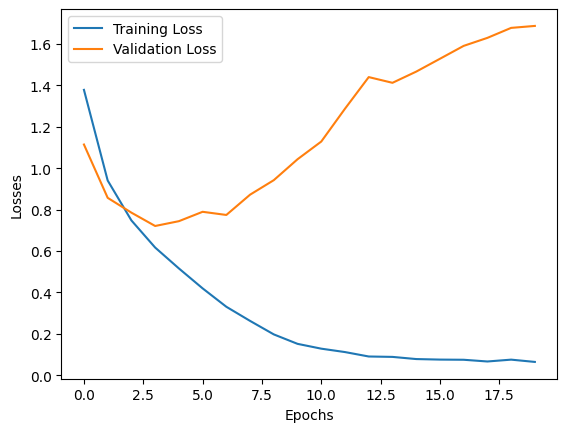

In [10]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [11]:
model.eval()

train_loss = 0.0
test_loss = 0.0

with torch.no_grad():
    
    # Training loss
    for xb, yb in train_loader:
        outputs = model(xb)
        loss = crietrion(outputs, yb)
        train_loss += loss.item()

    # Testing loss
    for xb, yb in test_loader:
        outputs = model(xb)
        loss = crietrion(outputs, yb)
        test_loss += loss.item()

train_loss = train_loss / len(train_loader)
test_loss = test_loss / len(test_loader)

print("Training Loss:", train_loss)
print("Testing Loss:", test_loss)

Training Loss: 0.487137053361939
Testing Loss: 0.7210630020897859


In [12]:
model.eval()

train_correct = 0
train_total = 0

test_correct = 0
test_total = 0

with torch.no_grad():

    # Training accuracy
    for xb, yb in train_loader:
        outputs = model(xb)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == yb).sum().item()
        train_total += yb.size(0)

    # Testing accuracy
    for xb, yb in test_loader:
        outputs = model(xb)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == yb).sum().item()
        test_total += yb.size(0)

train_accuracy = (train_correct / train_total) * 100
test_accuracy = (test_correct / test_total) * 100

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")

Training Accuracy: 83.64%
Testing Accuracy: 75.53%
